In [1]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

#define path of the file
filepath = r"C:\Users\abhis\Downloads\Prediction_data.xlsx"

#define the name of the sheet to read data from
sheetname = 'vw_churndata'

#read the data from the specified sheet into panda dataframe
df = pd.read_excel(filepath,sheet_name=sheetname)

#display first few rows of the data
print(df.head())


  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   19877-DEL    Male   35      No        Delhi                    7   
1   58353-MAH  Female   45     Yes  Maharashtra                   14   
2   25063-WES    Male   51      No  West Bengal                    4   
3   59787-KAR    Male   79      No    Karnataka                    3   
4   28544-TAM  Female   80      No   Tamil Nadu                    3   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                27        NaN           Yes             No  ...   
1                13        NaN           Yes            Yes  ...   
2                35     Deal 5           Yes             No  ...   
3                21     Deal 4           Yes             No  ...   
4                 8        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card           65.6        593.30          0.00   
1      Credit Card          

In [2]:
#Data processing
# Drop columns that won't be used for prediction
df = df.drop(['Customer_ID','Churn_Category','Churn_Reason'],axis=1)

In [3]:
df.columns

Index(['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals',
       'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract',
       'Paperless_Billing', 'Payment_Method', 'Monthly_Charge',
       'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges',
       'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status'],
      dtype='object')

In [4]:
#Label Encoding the categorical columns
columns_to_label = ['Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup','Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract','Paperless_Billing', 'Payment_Method'   
]

#Encode the variables except the target variable

label_encoders = {}
for column in columns_to_label:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

#now encode the target variable manually

df['Customer_Status'] = df['Customer_Status'].map({'Stayed':0,'Churned':1})

In [5]:
#split data into features and target
x = df.drop(['Customer_Status'], axis=1)  
y = df['Customer_Status']


#split data in training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [6]:
#training the model
#initialize the model
rf_model = RandomForestClassifier(n_estimators = 100,random_state=42)

#train the model
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
#Evaluating the model

#Predict the model
y_pred = rf_model.predict(x_test)

#Evaluate the model
print("Confusion Matrix: ")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report: ") 
print(classification_report(y_test,y_pred))

Confusion Matrix: 
[[803  52]
 [137 210]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       855
           1       0.80      0.61      0.69       347

    accuracy                           0.84      1202
   macro avg       0.83      0.77      0.79      1202
weighted avg       0.84      0.84      0.84      1202



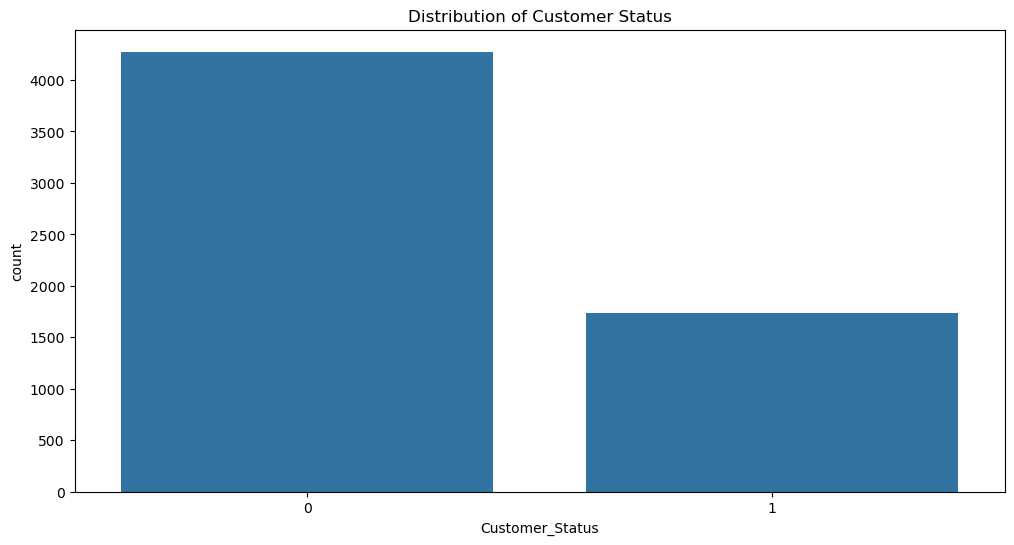

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(x="Customer_Status", data=df)
plt.title('Distribution of Customer Status')
plt.show()

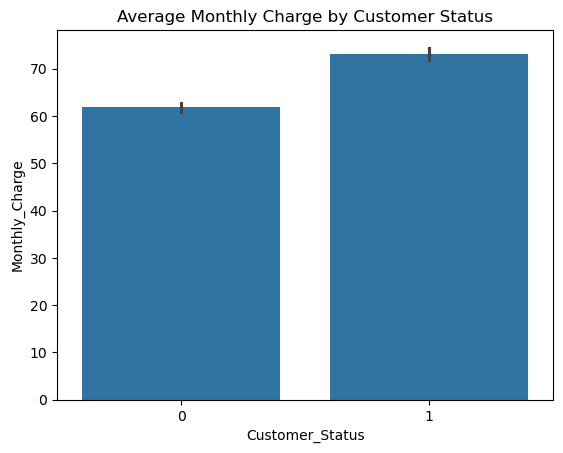

In [9]:
sns.barplot(x="Customer_Status", y="Monthly_Charge", data=df)
plt.title("Average Monthly Charge by Customer Status")
plt.show()


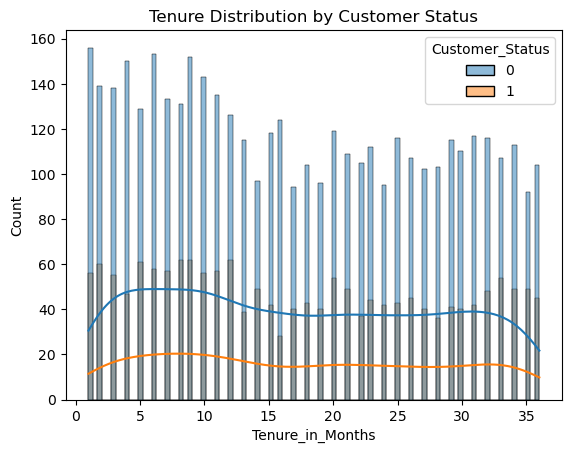

In [10]:
sns.histplot(data=df, x="Tenure_in_Months", hue="Customer_Status", kde=True, bins=100)
plt.title("Tenure Distribution by Customer Status")
plt.show()


In [11]:
# Get feature importances from the trained model
importances = rf_model.feature_importances_

# Sort indices by importance (descending order)
indices = np.argsort(importances)[::-1]

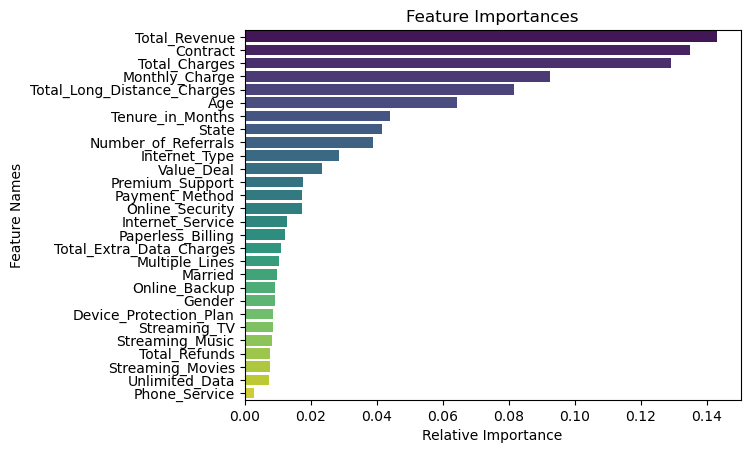

In [12]:
sns.barplot(x=importances[indices], y=x.columns[indices], hue=x.columns[indices], palette="viridis")
plt.title("Feature Importances")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Names")
plt.show()

In [13]:
#define path of the file
filepath = r"C:\Users\abhis\Downloads\Prediction_data.xlsx"

#define the name of the sheet to read data from
sheetname = 'vw_joindata'

#read the data from the specified sheet into panda dataframe
new_df = pd.read_excel(filepath,sheet_name=sheetname)

new_df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Yes,...,Bank Withdrawal,72.10,72.1,0.0,0,7.77,79.87,Joined,Others,Others
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,Yes,No,...,Credit Card,19.85,57.2,0.0,0,9.36,66.56,Joined,Others,Others
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,Yes,No,...,Credit Card,44.30,44.3,0.0,0,42.95,87.25,Joined,Others,Others
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,Yes,No,...,Credit Card,19.95,58.0,0.0,0,8.07,66.07,Joined,Others,Others
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,Yes,No,...,Credit Card,20.05,33.7,0.0,0,3.62,37.32,Joined,Others,Others


In [14]:
#retain the original dataframe to preserve unencoded columns
org_df = new_df.copy()

#retain the customer id column
customer_ids = new_df['Customer_ID']

In [15]:
#drop unused columns
new_df = new_df.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

#encode categorical variables
for column in new_df.select_dtypes(include=['object']).columns:
    new_df[column] = label_encoders[column].transform(new_df[column])

#make predictions with the training model
new_predictions = rf_model.predict(new_df)

#add predictions back to original dataframe
org_df['Customer_Status_Predicted'] = new_predictions

#filter only the churned customers
org_df = org_df[org_df['Customer_Status_Predicted'] == 1]

In [16]:
org_df.to_excel(r"C:\Users\abhis\Downloads\Prediction_data.xlsx")